# Notebook 02 : preprocessing déterministe

**Projet** : Laplace Immo, simulateur d'estimation de prix de maisons  
**Auteurs** : Astou DIALLO, Oumane SALL (EPT, DIC3)  
**Date** : juin 2026

## Objectif

Appliquer le nettoyage déterministe du dataset Ames Iowa et vérifier que :

- Les 2 outliers identifiés en analyse exploratoire sont bien retirés
- Les valeurs manquantes structurelles sont remplacées par `"None"` ou `0`
- Les variables connues uniquement après la vente sont exclues
- La colonne identifiant `Id` est supprimée

Toutes les opérations sont implémentées dans le module `src.preprocessing` et appelées ici pour visualisation et vérification.

Les imputations qui nécessitent une statistique apprise (médiane par quartier, mode) sont reportées au pipeline `sklearn` afin de respecter la rigueur anti data leakage : `fit` sur train uniquement.

## 1. Chargement des données brutes

In [1]:
# Imports standards
import sys
from pathlib import Path

# On ajoute la racine du projet au sys.path pour importer src/
chemin_projet = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(chemin_projet) not in sys.path:
    sys.path.insert(0, str(chemin_projet))

# Imports tiers
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Imports locaux
from src.data import charger_donnees, NOM_CIBLE
from src.preprocessing import (
    nettoyer_donnees,
    COLS_NAN_STRUCTURELLES_CATEGORIELLES,
    COLS_NAN_STRUCTURELLES_NUMERIQUES,
    VARS_LEAKAGE_METIER,
)

# Configuration affichage
pd.set_option("display.max_columns", 100)
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

# Chargement
df_brut = charger_donnees()
print(f"Shape brut : {df_brut.shape}")

Shape brut : (1460, 81)


In [2]:
# Apercu de l'etat initial des donnees
print(f"Nb total de NaN : {df_brut.isna().sum().sum()}")
print(f"Nb de colonnes avec NaN : {(df_brut.isna().sum() > 0).sum()}")
print(f"\nQuelques colonnes du DataFrame :")
print(list(df_brut.columns[:8]))

Nb total de NaN : 6965
Nb de colonnes avec NaN : 19

Quelques colonnes du DataFrame :
['Id', 'MSSubClass', 'MSZoning', 'LotFrontage', 'LotArea', 'Street', 'Alley', 'LotShape']


## 2. Application du nettoyage

On appelle l'orchestrateur `nettoyer_donnees` qui enchaîne les 5 fonctions de nettoyage dans le bon ordre :

1. `supprimer_outliers` (besoin de `SaleCondition`)
2. `imputer_nan_categorielles` (15 colonnes vers `"None"`)
3. `imputer_nan_numeriques` (2 colonnes vers `0`)
4. `supprimer_id`
5. `exclure_variables_leakage` (en dernier)

In [3]:
# Application du nettoyage
df_clean = nettoyer_donnees(df_brut)

In [4]:
# Comparaison avant / apres en tableau synthese
synthese = pd.DataFrame({
    "Avant": [
        df_brut.shape[0],
        df_brut.shape[1],
        df_brut.isna().sum().sum(),
        (df_brut.isna().sum() > 0).sum(),
    ],
    "Apres": [
        df_clean.shape[0],
        df_clean.shape[1],
        df_clean.isna().sum().sum(),
        (df_clean.isna().sum() > 0).sum(),
    ],
}, index=["Lignes", "Colonnes", "NaN total", "Colonnes avec NaN"])
synthese["Delta"] = synthese["Avant"] - synthese["Apres"]
synthese

,Avant,Apres,Delta
Lignes,1460,1458,2
Colonnes,81,76,5
NaN total,6965,260,6705
Colonnes avec NaN,19,2,17


## 3. Vérifications ciblées

On vérifie chaque transformation : un test visuel pour chacune des décisions de nettoyage.

In [5]:
# Verification 1 : les 2 outliers identifies en EDA ne sont plus dans le dataset
print("Outliers Id 524 et 1299 dans le dataset brut :")
print(df_brut[df_brut["Id"].isin([524, 1299])][["Id", "GrLivArea", "SaleCondition", NOM_CIBLE]])

print(f"\nDelta lignes : {df_brut.shape[0] - df_clean.shape[0]} (attendu : 2)")

Outliers Id 524 et 1299 dans le dataset brut :
        Id  GrLivArea SaleCondition  SalePrice
523    524       4676       Partial     184750
1298  1299       5642       Partial     160000

Delta lignes : 2 (attendu : 2)


In [6]:
# Verification 2 : les 4 variables de leakage et la colonne Id sont absentes du dataset nettoye
colonnes_a_verifier = VARS_LEAKAGE_METIER + ["Id"]
print("Verification de l'absence des variables exclues :\n")
for var in colonnes_a_verifier:
    statut = "PRESENT (erreur)" if var in df_clean.columns else "ABSENT (OK)"
    print(f"  {var:15s} -> {statut}")

Verification de l'absence des variables exclues :

  SaleType        -> ABSENT (OK)
  SaleCondition   -> ABSENT (OK)
  MoSold          -> ABSENT (OK)
  YrSold          -> ABSENT (OK)
  Id              -> ABSENT (OK)


In [7]:
# Verification 3 : aucun NaN structurel ne reste
nan_restants = df_clean.isna().sum()
nan_restants = nan_restants[nan_restants > 0].sort_values(ascending=False)

print("Colonnes avec NaN restants apres nettoyage :")
print(nan_restants)

print(f"\nAttendu : LotFrontage (259) et Electrical (1) uniquement")
print(f"Total NaN restants : {nan_restants.sum()} (attendu : 260)")
print(f"\nCes NaN seront traites par le pipeline sklearn (mediane de quartier + mode).")

Colonnes avec NaN restants apres nettoyage :
LotFrontage    259
Electrical       1
dtype: int64

Attendu : LotFrontage (259) et Electrical (1) uniquement
Total NaN restants : 260 (attendu : 260)

Ces NaN seront traites par le pipeline sklearn (mediane de quartier + mode).


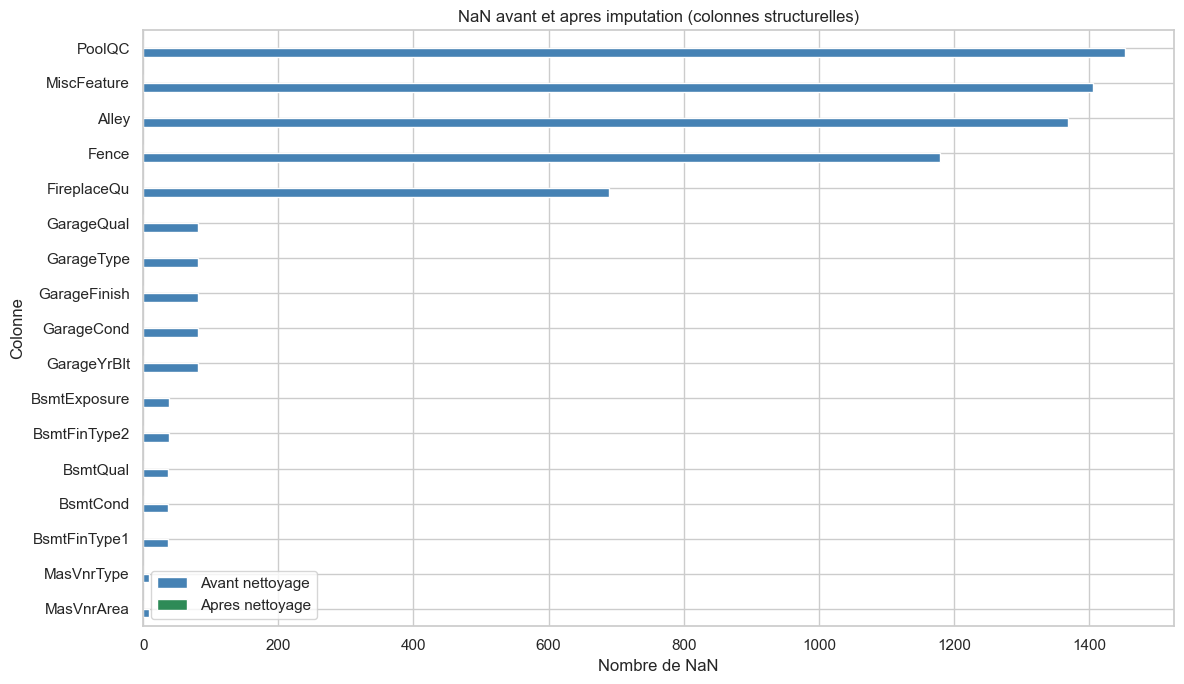

In [8]:
# Visualisation : reduction des NaN sur les colonnes imputees
colonnes_imputees = COLS_NAN_STRUCTURELLES_CATEGORIELLES + COLS_NAN_STRUCTURELLES_NUMERIQUES
comparaison = pd.DataFrame({
    "Avant nettoyage": df_brut[colonnes_imputees].isna().sum(),
    "Apres nettoyage": df_clean[colonnes_imputees].isna().sum(),
}).sort_values("Avant nettoyage", ascending=True)

fig, ax = plt.subplots(figsize=(12, 7))
comparaison.plot(kind="barh", ax=ax, color=["steelblue", "seagreen"])
ax.set_title("NaN avant et apres imputation (colonnes structurelles)")
ax.set_xlabel("Nombre de NaN")
ax.set_ylabel("Colonne")
plt.tight_layout()
plt.show()

## 4. Synthèse

Le nettoyage déterministe a transformé le dataset :

| Métrique | Avant | Après | Delta |
|---|---|---|---|
| Lignes | 1 460 | 1 458 | -2 outliers `Partial` |
| Colonnes | 81 | 76 | -1 `Id` et -4 variables de leakage |
| NaN total | 6 965 | 260 | 6 705 NaN structurels imputés |
| Colonnes avec NaN | 19 | 2 | 17 colonnes nettoyées |

Les 260 NaN restants se concentrent sur `LotFrontage` (259) et `Electrical` (1). Ils seront traités par le pipeline `sklearn` avec une imputation par médiane de quartier et par mode, en garantissant que la statistique ne soit calculée que sur les données d'entraînement.

Le DataFrame nettoyé `df_clean` est prêt pour l'étape suivante : la création de features (feature engineering).